# Syinthetic data - retweeted mostly by Republican registered users

In [ ]:
import sys
sys.path.insert(0,'..')

Imports:

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import json


from emoatlas import *
import nltk
import networkx as nx

Import stopwords to look at non-stopwords focal terms later:

In [5]:
from nltk.corpus import stopwords

# NLTK resources commonly needed for EmoAtlas + downstream text filtering
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

SPACY_MODEL = "en_core_web_sm"

# shortcut for eomatlas, using the default English spacy model
emo = EmoScores(language="english", spacy_model=SPACY_MODEL)


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Now load the JSON file containing the titles generated using Claude

In [6]:
with open(r"../data/synth_rep_titles.json", "r") as f:
    data = json.load(f)

df_2016 = pd.DataFrame(data["articles"]["2016-04-22"])
df_2017=pd.DataFrame(data["articles"]["2017-04-22"])

print(df_2016.head())

   id                                              title
0   1  The Paris Climate Agreement Is a Bad Deal That...
1   2  Earth Day Fearmongering: Why Climate Alarmists...
2   3  The Climate Change Agenda Is Really About Redi...
3   4  How the Paris Climate Deal Gives China a Pass ...
4   5  Obama Signs Climate Agreement Without Senate A...


In [7]:
# append all the titles together to create a tfmn
titles_2016 = ' '.join(df_2016['title'].tolist())
titles_2017 = ' '.join(df_2017['title'].tolist())

2016 data, emotional flower:

Emotional words count:

{'anger': 14, 'trust': 30, 'surprise': 9, 'disgust': 6, 'joy': 22, 'sadness': 13, 'fear': 21, 'anticipation': 11}


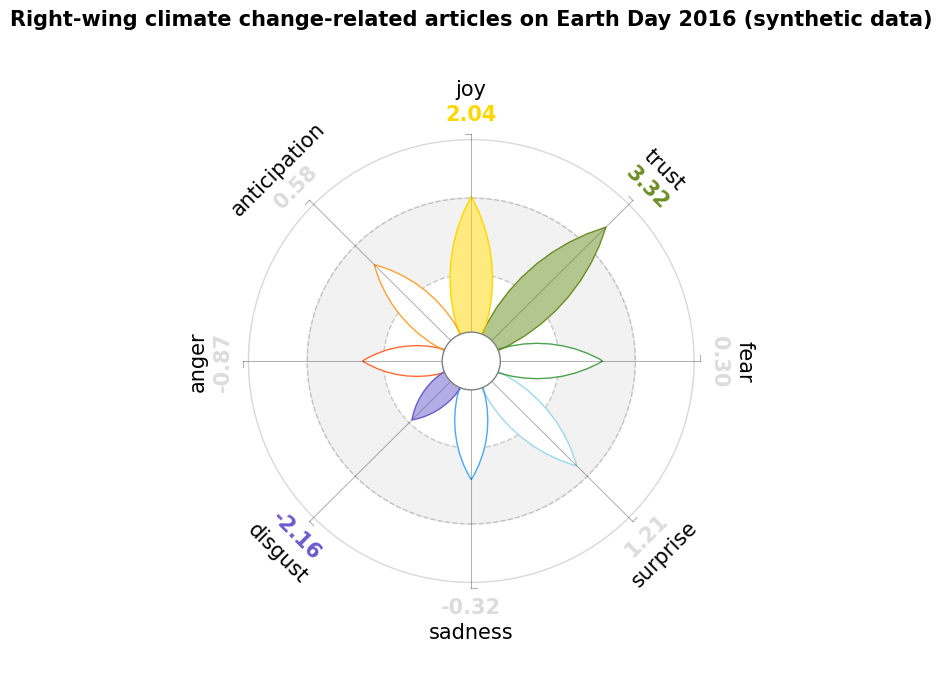

In [8]:
fmnt_2016 = emo.formamentis_network(titles_2016)

emotion_counts_2016 = emo.emotions(titles_2016)
print('Emotional words count:\n')
print(emotion_counts_2016)
zscores_2016 = emo.zscores(titles_2016)
emo.draw_statistically_significant_emotions(fmnt_2016, title='Right-wing climate change-related articles on Earth Day 2016 (synthetic data)')

Network statistics analysis:

In [9]:
# rank salient terms (closeness centrality)
graph_2016 = emo.formamentis_to_nxgraph(fmnt_2016)
degree_dict = dict(graph_2016.degree())
closeness_dict = nx.closeness_centrality(graph_2016)

top_terms_df_2016 = pd.DataFrame(
    {
        "term": list(graph_2016.nodes()),
        "degree": [degree_dict[node] for node in graph_2016.nodes()],
        "closeness": [closeness_dict[node] for node in graph_2016.nodes()],
    }
)

# filter to only alphabetic and non-stopword
top_terms_df_2016["is_alpha"] = top_terms_df_2016["term"].astype(str).str.fullmatch(r"[A-Za-z]+")
top_terms_df_2016["usable_term"] = (
    top_terms_df_2016["is_alpha"].fillna(False)
    & (~top_terms_df_2016["term"].astype(str).str.lower().isin(stop_words))
    & (top_terms_df_2016["term"].astype(str).str.len() >= 4)
)

top_terms_df_2016 = top_terms_df_2016.sort_values(["degree", "closeness"], ascending=False).reset_index(drop=True)

print("Graph size:")
print("Nodes:", graph_2016.number_of_nodes())
print("Edges:", graph_2016.number_of_edges())

top_terms_df_2016 = top_terms_df_2016.loc[top_terms_df_2016["usable_term"]].reset_index(drop=True)
print("\nTop alphabetic, non-stopword terms, by saliency:")
display(top_terms_df_2016.head(10))

Graph size:
Nodes: 205
Edges: 1203

Top alphabetic, non-stopword terms, by saliency:


,term,degree,closeness,is_alpha,usable_term
0,climate,96,0.628992,True,True
1,cost,56,0.560279,True,True
2,change,50,0.534812,True,True
3,deal,49,0.533386,True,True
4,energy,43,0.515514,True,True
5,regulation,40,0.510254,True,True
6,agreement,37,0.502562,True,True
7,reject,36,0.510254,True,True
8,drive,36,0.505100,True,True
9,kill,36,0.503828,True,True


The most salient word is *change*, which is the focal term. Let's look at its semantic frame and at the most significant emotions the frame conveys. 

Semantic frame theory affirms that it is possible to partly reconstruct the meaning of a word based on its textual context

In [10]:
if top_terms_df_2016.empty:
    raise ValueError("No usable focal term was found in the combined network.")

focal_term = top_terms_df_2016.iloc[0]["term"]
focal_fmn = emo.extract_word_from_formamentis(fmnt_2016, focal_term)
# only taking the connection to focal_term


if not focal_fmn.vertices:
    raise ValueError(f"No semantic frame could be extracted for term: {focal_term}")

print("Chosen focal term:", focal_term)
print("Semantic-frame vertices:", len(focal_fmn.vertices))
print("Semantic-frame terms:", sorted(focal_fmn.vertices))

Chosen focal term: climate
Semantic-frame vertices: 97
Semantic-frame terms: ['abundant', 'accord', 'action', 'activist', 'admit', 'advocacy', 'agenda', 'agreement', 'alarmism', 'alarmist', 'america', 'american', 'americans', 'bill', 'billion', 'bureaucrat', 'business', 'celebrate', 'change', 'china', 'climate', 'close', 'community', 'consensus', 'corrupt', 'cost', 'credibility', 'czar', 'day', 'deal', 'debate', 'destroy', 'devastation', 'disaster', 'door', 'drive', 'economy', 'electric', 'emergency', 'energy', 'epa', 'exaggeration', 'force', 'funding', 'grab', 'horse', 'hurt', 'hysteria', 'important', 'industry', 'kill', 'laugh', 'left', 'legacy', 'live', 'lobby', 'loss', 'manufacturer', 'money', 'movement', 'obama', 'orthodoxy', 'outlast', 'paris', 'pass', 'pay', 'plan', 'policy', 'politic', 'predict', 'profit', 'promise', 'push', 'radical', 'raise', 'regulation', 'reject', 'renegotiate', 'sacrifice', 'science', 'senate', 'send', 'shape', 'sign', 'sovereignty', 'spending', 'state', '

Textual Forma Mentis Network of the most salient words linked to the focal word (given the size of the dataset, looking at the whole semantic frame would be useless). The words taken into accounts are all those with a top 25% salience (over the 75% quantile).

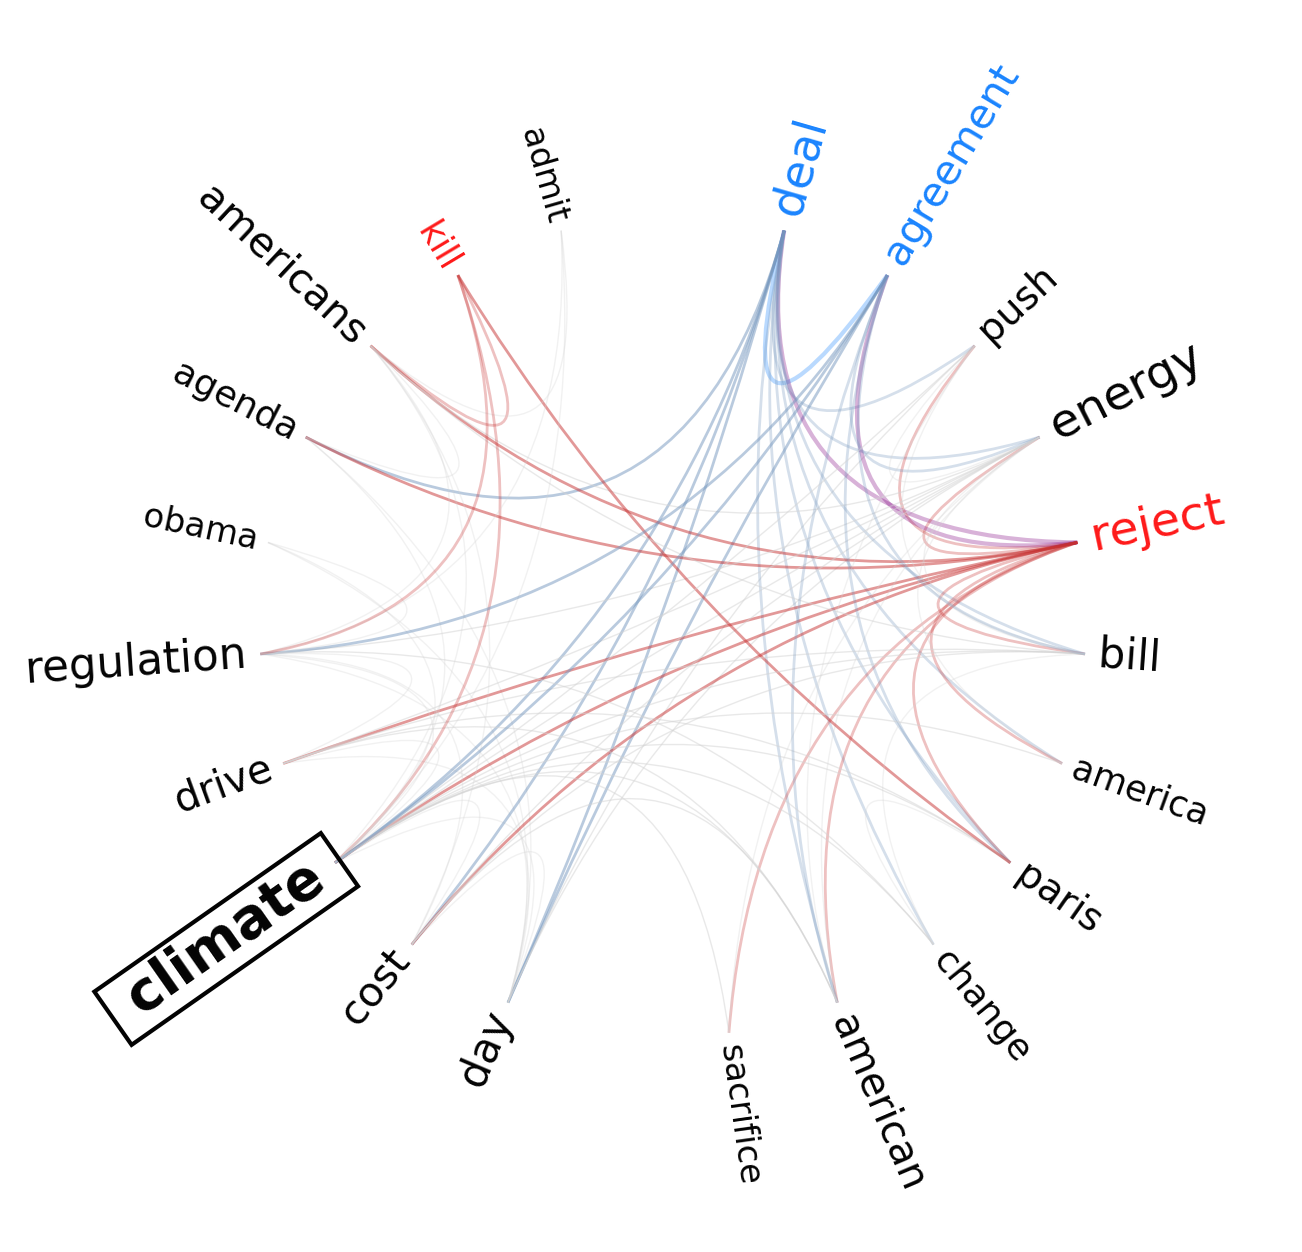

In [11]:
focal_graph = emo.formamentis_to_nxgraph(focal_fmn)
closeness_dict = nx.closeness_centrality(focal_graph)

top_terms_df_focal = pd.DataFrame(
    {
        "term": list(focal_graph.nodes()),
        "closeness": [closeness_dict[node] for node in focal_graph.nodes()],
    }
)

# go over all the edges, only keep the ones with third quartile salience
t=np.quantile(list(top_terms_df_focal['closeness']),0.75)
df_t=top_terms_df_focal[top_terms_df_focal['closeness']>t]
top_edges=[]
top_nodes=df_t['term'][:10]



for v in top_nodes:
    for (e1,e2) in list(focal_graph.edges):
        if v in (e1,e2):
                    if e1 in list(df_t['term']) and e2 in list(df_t['term']):
                             top_edges.append((e1,e2))

top_graph=nx.Graph()
top_graph.add_nodes_from(top_nodes)
top_graph.add_edges_from(top_edges)

top_focal_fmnt=emo.nxgraph_to_formamentis(top_graph)

top_edges
emo.draw_formamentis(top_focal_fmnt, highlight=[focal_term])


Emotional flower of the semantic frame:

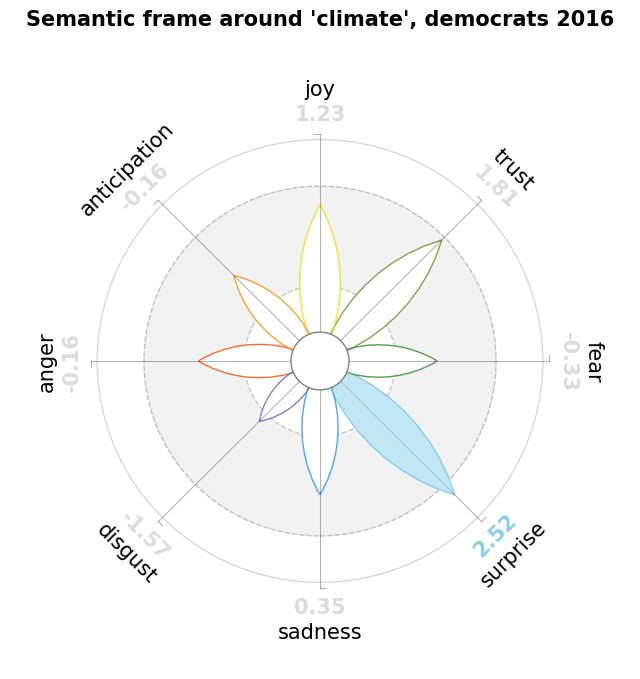

In [12]:
# Important:
# draw_formamentis_flower() expects raw text and rebuilds a new network from that text.
# Here we already have the extracted semantic-frame network, so the correct call is to pass
# the Formamentis Network directly to draw_statistically_significant_emotions().
emo.draw_statistically_significant_emotions(
    focal_fmn,
    title=f"Semantic frame around '{focal_term}', democrats 2016",
)

Now let's do the same for 2017 data.

First, emotional flower

Emotional words count:

{'anger': 13, 'trust': 30, 'surprise': 9, 'disgust': 9, 'joy': 17, 'sadness': 13, 'fear': 18, 'anticipation': 20}


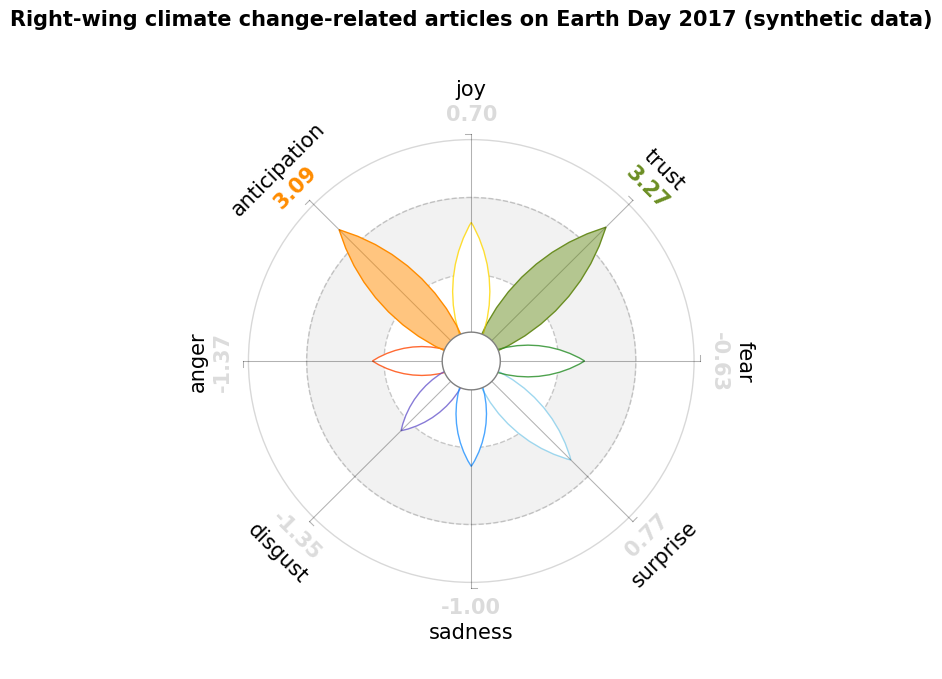

In [13]:
fmnt_2017 = emo.formamentis_network(titles_2017)
emotion_counts_2017 = emo.emotions(titles_2017)
print('Emotional words count:\n')
print(emotion_counts_2017)
zscores_2017 = emo.zscores(titles_2017)
emo.draw_statistically_significant_emotions(fmnt_2017, title='Right-wing climate change-related articles on Earth Day 2017 (synthetic data)')

Network statistics analysis:

In [14]:
# rank salient terms (closeness centrality)
graph_2017 = emo.formamentis_to_nxgraph(fmnt_2017)
degree_dict = dict(graph_2017.degree())
closeness_dict = nx.closeness_centrality(graph_2017)

top_terms_df_2017 = pd.DataFrame(
    {
        "term": list(graph_2017.nodes()),
        "degree": [degree_dict[node] for node in graph_2017.nodes()],
        "closeness": [closeness_dict[node] for node in graph_2017.nodes()],
    }
)

# filter to only alphabetic and non-stopword
top_terms_df_2017["is_alpha"] = top_terms_df_2017["term"].astype(str).str.fullmatch(r"[A-Za-z]+")
top_terms_df_2017["usable_term"] = (
    top_terms_df_2017["is_alpha"].fillna(False)
    & (~top_terms_df_2017["term"].astype(str).str.lower().isin(stop_words))
    & (top_terms_df_2017["term"].astype(str).str.len() >= 4)
)

top_terms_df_2017 = top_terms_df_2017.sort_values(["degree", "closeness"], ascending=False).reset_index(drop=True)

print("Graph size:")
print("Nodes:", graph_2017.number_of_nodes())
print("Edges:", graph_2017.number_of_edges())

filtered_terms_df_2017 = top_terms_df_2017.loc[top_terms_df_2017["usable_term"]].reset_index(drop=True)
print("\nTop alphabetic, non-stopword terms, by saliency:")
display(filtered_terms_df_2017.head(10))



Graph size:
Nodes: 222
Edges: 1425

Top alphabetic, non-stopword terms, by saliency:


,term,degree,closeness,is_alpha,usable_term
0,climate,132,0.704604,True,True
1,change,65,0.559325,True,True
2,follow,49,0.522935,True,True
3,deserve,47,0.526743,True,True
4,march,46,0.534527,True,True
5,regulation,41,0.514261,True,True
6,american,41,0.470755,True,True
7,agenda,33,0.508239,True,True
8,protect,33,0.502357,True,True
9,policy,33,0.494346,True,True


The most salient word is *climate*, this time. Let's look at reduced FMNT (with the same third quartile threshold as before) and emotional flower of the semantic frame.

In [15]:
if top_terms_df_2017.empty:
    raise ValueError("No usable focal term was found in the combined network.")

focal_term = top_terms_df_2017.iloc[0]["term"]
focal_fmn = emo.extract_word_from_formamentis(fmnt_2017, focal_term)
# only taking the connection to focal_term


if not focal_fmn.vertices:
    raise ValueError(f"No semantic frame could be extracted for term: {focal_term}")

print("Chosen focal term:", focal_term)
print("Semantic-frame vertices:", len(focal_fmn.vertices))
print("Semantic-frame terms:", sorted(focal_fmn.vertices))

Chosen focal term: climate
Semantic-frame vertices: 133
Semantic-frame terms: ['abandon', 'abundance', 'accept', 'action', 'activist', 'advocacy', 'agenda', 'ago', 'agreement', 'alarmism', 'alarmist', 'america', 'americans', 'answer', 'beat', 'billion', 'bureaucracy', 'bureaucrat', 'catastrophe', 'change', 'climate', 'coat', 'commitment', 'community', 'concern', 'congress', 'consensus', 'cost', 'cover', 'coverage', 'create', 'crime', 'crisis', 'crusade', 'day', 'deal', 'debate', 'democrats', 'deserve', 'destroy', 'disagree', 'earth', 'eliminate', 'emergency', 'environmentalist', 'epa', 'evidence', 'exit', 'federalism', 'fly', 'follow', 'gas', 'good', 'government', 'grant', 'hear', 'hearing', 'hysteria', 'ideologue', 'industry', 'infect', 'jet', 'job', 'kill', 'leave', 'left', 'lobby', 'look', 'manufacture', 'march', 'marcher', 'medium', 'million', 'model', 'money', 'movement', 'narrative', 'neutral', 'obama', 'organize', 'organizer', 'overreach', 'paris', 'partisan', 'policy', 'politic

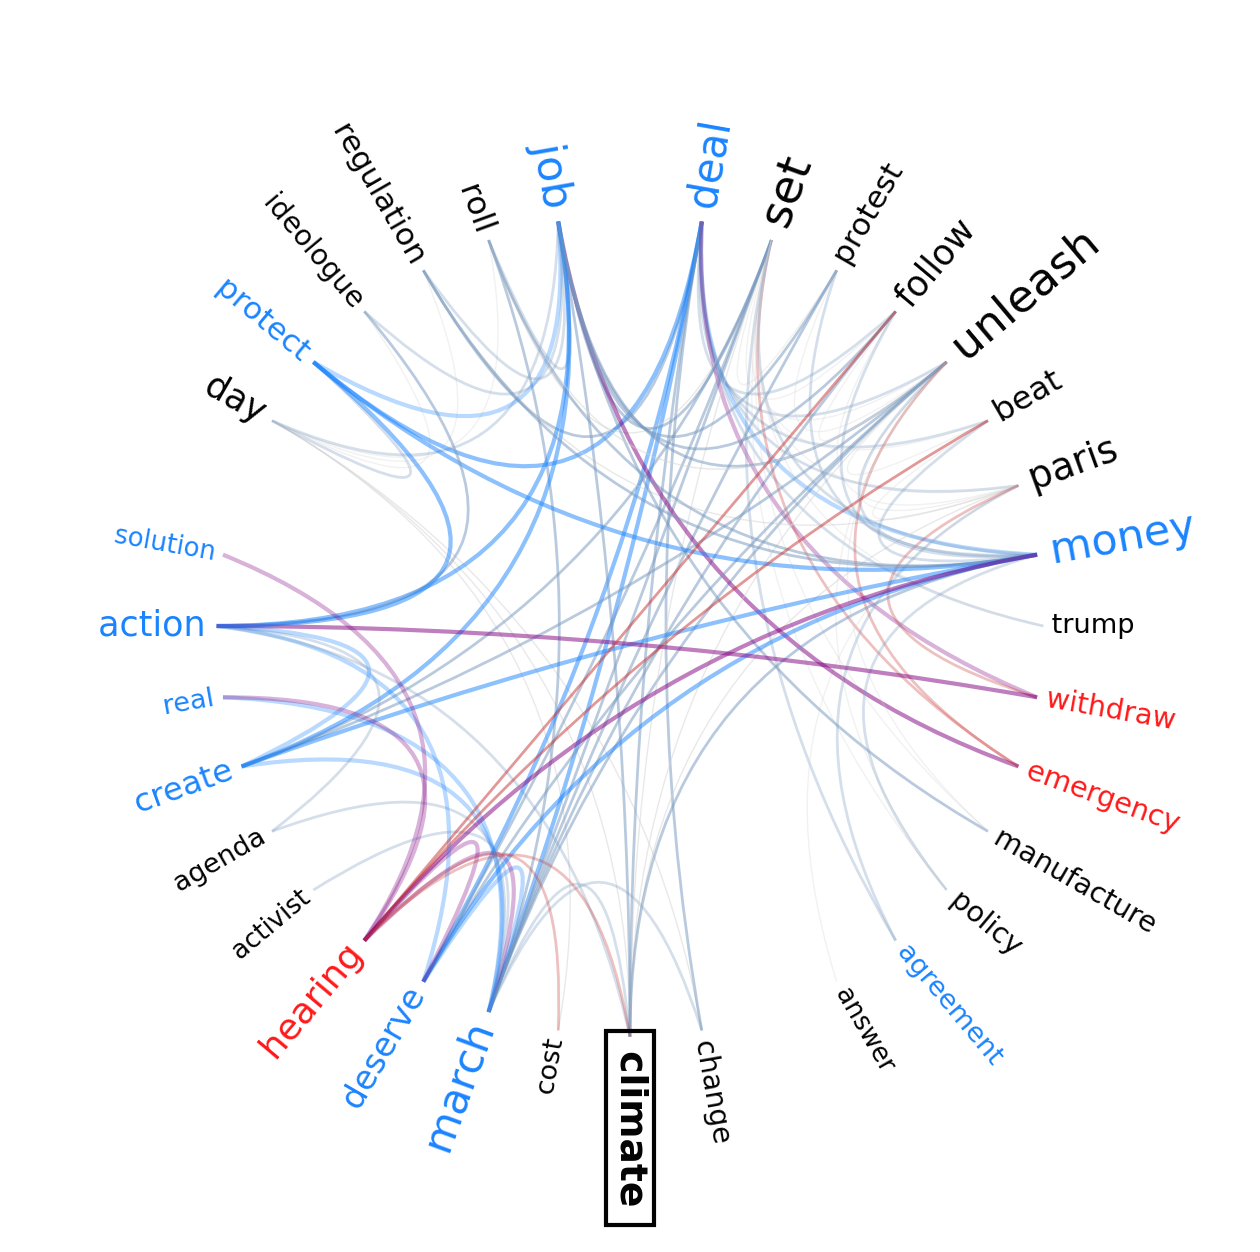

In [16]:
focal_graph = emo.formamentis_to_nxgraph(focal_fmn)
closeness_dict = nx.closeness_centrality(focal_graph)

top_terms_df_focal = pd.DataFrame(
    {
        "term": list(focal_graph.nodes()),
        "closeness": [closeness_dict[node] for node in focal_graph.nodes()],
    }
)

# go over all the edges, only keep the ones with third quartile salience
t=np.quantile(list(top_terms_df_focal['closeness']),0.75)
df_t=top_terms_df_focal[top_terms_df_focal['closeness']>t]
top_edges=[]
top_nodes=df_t['term'][:10]



for v in top_nodes:
    for (e1,e2) in list(focal_graph.edges):
        if v in (e1,e2):
                    if e1 in list(df_t['term']) and e2 in list(df_t['term']):
                             top_edges.append((e1,e2))

top_graph=nx.Graph()
top_graph.add_nodes_from(top_nodes)
top_graph.add_edges_from(top_edges)

top_focal_fmnt=emo.nxgraph_to_formamentis(top_graph)

top_edges
emo.draw_formamentis(top_focal_fmnt, highlight=[focal_term])

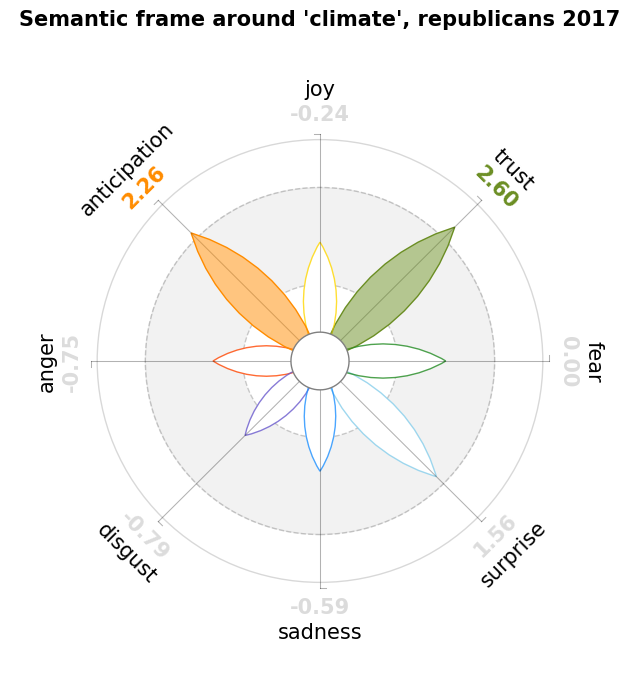

In [17]:
emo.draw_statistically_significant_emotions(
    focal_fmn,
    title=f"Semantic frame around '{focal_term}', republicans 2017",
)

And then you can save all key outputs for downstream work

In [18]:
# from pathlib import Path
# OUTPUT_DIR = Path("./emoatlas_outputs_republicans")
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# # Core tabular outputs
# df_2016.to_pickle(OUTPUT_DIR / "all_json_flattened.pkl")
# df_2016.to_csv(OUTPUT_DIR / "all_json_flattened.csv", index=False)

# df_2017.to_pickle(OUTPUT_DIR / "all_json_flattened.pkl")
# df_2017.to_csv(OUTPUT_DIR / "all_json_flattened.csv", index=False)


# # network_stats_df.to_csv(OUTPUT_DIR / "first_50_tfmn_stats.csv", index=False)
# top_terms_df_2016.to_csv(OUTPUT_DIR / "combined_network_top_terms_2016.csv", index=False)

# top_terms_df_2017.to_csv(OUTPUT_DIR / "combined_network_top_terms_2017.csv", index=False)


# # Export the aggregated formamentis network as a simple text edgelist
# emo.export_formamentis(
#     fmnt_2016,
#     filename="2016_formamentis.txt",
#     path=str(OUTPUT_DIR),
# )

# emo.export_formamentis(
#     fmnt_2017,
#     filename="2017_formamentis.txt",
#     path=str(OUTPUT_DIR),
# )

# print("Saved output files:")
# for path in sorted(OUTPUT_DIR.iterdir()):
#     print("-", path)